In [226]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

import re

In [227]:
analysis_df = pd.read_csv('../data/processed/analysis_multi.csv',
                          header=[0, 1], index_col=0)
analysis_df.index = pd.to_datetime(analysis_df.index)
analysis_df.columns

MultiIndex([(  'PX', 'ESH1'),
            (  'PX', 'ESM1'),
            (  'PX', 'ESU1'),
            (  'PX', 'ESZ1'),
            (  'PX', 'ESH2'),
            (  'PX', 'ESM2'),
            (  'PX', 'ESU2'),
            (  'PX', 'ESZ2'),
            (  'PX', 'ESH3'),
            (  'PX', 'ESM3'),
            (  'PX', 'ESU3'),
            (  'PX', 'ESZ3'),
            (  'PX', 'ESH4'),
            (  'PX', 'ESM4'),
            (  'PX', 'ESU4'),
            (  'PX', 'ESZ4'),
            (  'PX', 'ESH5'),
            (  'PX', 'ESM5'),
            (  'PX', 'ESU5'),
            (  'PX', 'ESZ5'),
            (  'PX', 'ESH6'),
            (  'PX', '^SPX'),
            (  'PX',   '1M'),
            (  'PX',   '3M'),
            (  'PX',   '6M'),
            (  'PX',  '12M'),
            (  'PX',    'q'),
            (   'T', 'ESZ1'),
            (   'T', 'ESH2'),
            (   'T', 'ESM2'),
            (   'T', 'ESU2'),
            (   'T', 'ESZ2'),
            (   'T', 'ESH3'),
          

In [228]:
contracts = analysis_df.columns.get_level_values(1).unique()
contracts

Index(['ESH1', 'ESM1', 'ESU1', 'ESZ1', 'ESH2', 'ESM2', 'ESU2', 'ESZ2', 'ESH3',
       'ESM3', 'ESU3', 'ESZ3', 'ESH4', 'ESM4', 'ESU4', 'ESZ4', 'ESH5', 'ESM5',
       'ESU5', 'ESZ5', 'ESH6', '^SPX', '1M', '3M', '6M', '12M', 'q'],
      dtype='str', name='contract')

In [229]:
futures = [
    c for c in contracts
    if re.fullmatch(r'ES[HMUZ]\d+', c)
]
print(futures)

['ESH1', 'ESM1', 'ESU1', 'ESZ1', 'ESH2', 'ESM2', 'ESU2', 'ESZ2', 'ESH3', 'ESM3', 'ESU3', 'ESZ3', 'ESH4', 'ESM4', 'ESU4', 'ESZ4', 'ESH5', 'ESM5', 'ESU5', 'ESZ5', 'ESH6']


In [230]:
analysis_df['Fair'].columns
# 'ESH1', 'ESM1', 'ESU1' are not exist so we won't include them in our strategy

Index(['ESZ1', 'ESH2', 'ESM2', 'ESU2', 'ESZ2', 'ESH3', 'ESM3', 'ESU3', 'ESZ3',
       'ESH4', 'ESM4', 'ESU4', 'ESZ4', 'ESH5', 'ESM5', 'ESU5', 'ESZ5', 'ESH6'],
      dtype='str', name='contract')

In [231]:
exclude = ['ESH1', 'ESM1', 'ESU1']
futures = [f for f in futures if f not in exclude]
print(futures)

['ESZ1', 'ESH2', 'ESM2', 'ESU2', 'ESZ2', 'ESH3', 'ESM3', 'ESU3', 'ESZ3', 'ESH4', 'ESM4', 'ESU4', 'ESZ4', 'ESH5', 'ESM5', 'ESU5', 'ESZ5', 'ESH6']


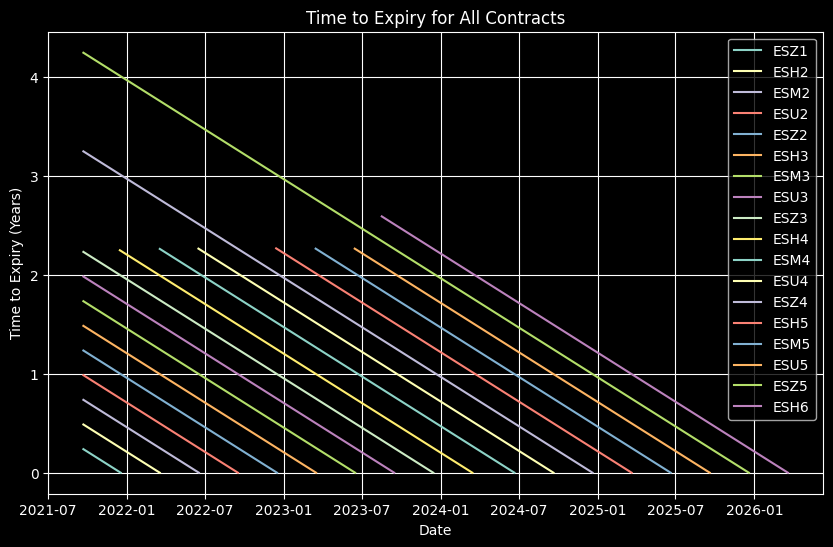

In [232]:
plt.figure(figsize=(10, 6))

for col in analysis_df['T'].columns:
    plt.plot(
        analysis_df.index,
        analysis_df['T'][col],
        label=col
    )

plt.xlabel("Date")
plt.ylabel("Time to Expiry (Years)")
plt.title("Time to Expiry for All Contracts")
plt.legend()
plt.grid(True)

plt.show()

In [233]:
# TO-DO List
# 1. start with a systematic short (Buy F1 -> Sell F2)
# roll it to the nearest contract before expiry (T-3, T-4, T-5)
# 2. determine the best time to roll, incorporate volume / open interest if possible
# 3. research the initial setting

In [234]:
# Initial setting (require research)
INITIAL_NAV = 100_000_000 # USD
MULTIPLIER = 50 # E-Mini Futures (Benni)
T_COST = 2.5 # USD per contract per trade (Benni)
ROLL_WINDOW = 5 / 365 # Days before maturity
# N_CONTRACTS # Number of contracts for hedging (Damien)

In [235]:
fut_price = analysis_df['PX'][futures]
fair_price = analysis_df['Fair'][futures]

In [236]:
T = analysis_df['T']

In [237]:
front_idx = 0

F1 = pd.Series(index=fut_price.index, dtype=object)
F2 = pd.Series(index=fut_price.index, dtype=object)

In [238]:
for i, date in enumerate(fut_price.index):
    front = futures[front_idx]
    # roll condition
    if T.loc[date, front] <= ROLL_WINDOW:
        if front_idx < len(futures) - 1:
            front_idx += 1

    # assign AFTER deciding
    F1.iloc[i] = futures[front_idx]
    # F2.iloc[i] = futures[front_idx + 1]

In [239]:
# F = pd.DataFrame({
#     'F1': F1,
#     'F2': F2
# })
# F.to_csv('../data/processed/F.csv')

In [240]:
positions = pd.DataFrame(0,
            index=fut_price.index,
            columns=futures
            )
for date in positions.index:
    positions.loc[date, F1.loc[date]] = -1 # date, contract that we are shorting

positions.to_csv('../data/backtest/positions.csv')

In [241]:
trades = positions.diff().abs().sum(axis=1)
roll_dates = trades[trades==2]
roll_dates

Date
2021-12-13    2.0
2022-03-14    2.0
2022-06-13    2.0
2022-09-12    2.0
2022-12-12    2.0
2023-03-13    2.0
2023-06-12    2.0
2023-09-11    2.0
2023-12-11    2.0
2024-03-11    2.0
2024-06-17    2.0
2024-09-16    2.0
2024-12-16    2.0
2025-03-17    2.0
2025-06-16    2.0
2025-09-15    2.0
2025-12-15    2.0
dtype: float64

In [242]:
transaction_cost = trades * T_COST

In [243]:
price_diff = fut_price.diff()

raw_pnl = (
    positions.shift(1) * price_diff
).sum(axis=1) * MULTIPLIER
fut_price

contract,ESZ1,ESH2,ESM2,ESU2,ESZ2,ESH3,ESM3,ESU3,ESZ3,ESH4,ESM4,ESU4,ESZ4,ESH5,ESM5,ESU5,ESZ5,ESH6
Date,,,,,,,,,,,,,,,,,,
2021-09-21,4343.25,4335.75,4325.75,4321.25,4312.25,4303.50,4294.50,4295.00,4292.00,NaN,NaN,NaN,4284.50,NaN,NaN,NaN,4289.50,NaN
2021-09-22,4384.00,4376.50,4366.25,4360.50,4351.50,4342.50,4333.50,4334.00,4331.00,NaN,NaN,NaN,4323.50,NaN,NaN,NaN,4328.50,NaN
2021-09-23,4438.00,4430.50,4420.25,4412.75,4403.25,4393.75,4384.25,4384.50,4381.50,NaN,NaN,NaN,4374.00,NaN,NaN,NaN,4379.00,NaN
2021-09-24,4445.75,4438.25,4428.00,4419.00,4412.50,4403.75,4394.75,4395.25,4394.25,NaN,NaN,NaN,4396.75,NaN,NaN,NaN,4401.75,NaN
2021-09-27,4433.00,4425.50,4415.50,4408.50,4399.50,4390.75,4381.75,4382.25,4381.25,NaN,NaN,NaN,4383.75,NaN,NaN,NaN,4388.75,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6594.63
2026-03-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [244]:
raw_pnl

Date
2021-09-21       0.0
2021-09-22   -2037.5
2021-09-23   -2700.0
2021-09-24    -387.5
2021-09-27     637.5
               ...  
2026-03-20     731.0
2026-03-23       0.0
2026-03-24       0.0
2026-03-25       0.0
2026-03-26       0.0
Length: 1124, dtype: float64

In [245]:
net_pnl = raw_pnl - transaction_cost
NAV = INITIAL_NAV + net_pnl.cumsum()
NAV

Date
2021-09-21    100000000.0
2021-09-22     99997962.5
2021-09-23     99995262.5
2021-09-24     99994875.0
2021-09-27     99995512.5
                 ...     
2026-03-20     99922533.5
2026-03-23     99922533.5
2026-03-24     99922533.5
2026-03-25     99922533.5
2026-03-26     99922533.5
Length: 1124, dtype: float64

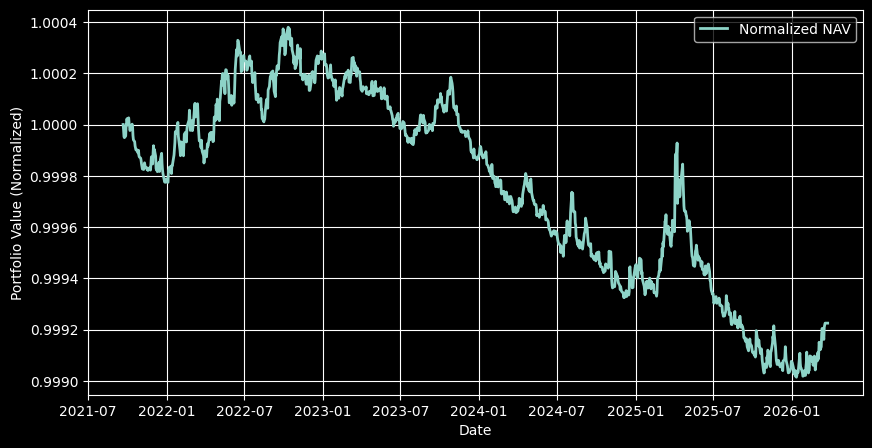

In [246]:
NAV_norm = NAV / NAV.iloc[0]
plt.figure(figsize=(10, 5))

plt.plot(NAV_norm.index, NAV_norm.values, label='Normalized NAV', linewidth=2)

plt.xlabel('Date')
plt.ylabel('Portfolio Value (Normalized)')
plt.legend()
plt.grid(True)

plt.show()